# Sentiment Analysis using NLP Pipeline & ML Models
## Data Science Internship – February 2026

### Objective
The aim of this project is to build a complete sentiment analysis system using NLP preprocessing, feature engineering, and machine learning models. The dataset contains text reviews with sentiment labels. The text is cleaned, converted into numerical features, and then used to train multiple models. Finally, the models are evaluated and compared.

In [1]:
# ============================================================
# SENTIMENT ANALYSIS USING NLP PIPELINE & ML MODELS
# AMAZON REVIEW DATASETS
# ============================================================

# =========================
# 1. INSTALL / IMPORT
# =========================
!pip install nltk -q

import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from google.colab import drive
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Download only required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# =========================
# 2. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# =========================
# 3. UNZIP DATASET
# =========================
!unzip -o "/content/drive/MyDrive/NLP/archive.zip" -d /content/data

# Check extracted files
!ls /content/data


Archive:  /content/drive/MyDrive/NLP/archive.zip
  inflating: /content/data/1429_1.csv  
  inflating: /content/data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv  
  inflating: /content/data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv  
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [4]:
# =========================
# 4. LOAD ALL 3 CSV FILES
# =========================
df1 = pd.read_csv("/content/data/1429_1.csv", low_memory=False)
df2 = pd.read_csv("/content/data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv", low_memory=False)
df3 = pd.read_csv("/content/data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv", low_memory=False)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
print("Dataset 3 shape:", df3.shape)


Dataset 1 shape: (34660, 21)
Dataset 2 shape: (5000, 24)
Dataset 3 shape: (28332, 24)


In [5]:
# =========================
# 5. SELECT REQUIRED COLUMNS
# =========================
df1 = df1[['reviews.text', 'reviews.rating']].copy()
df2 = df2[['reviews.text', 'reviews.rating']].copy()
df3 = df3[['reviews.text', 'reviews.rating']].copy()

# Combine all datasets
df = pd.concat([df1, df2, df3], ignore_index=True)

print("Combined dataset shape:", df.shape)
print(df.head())

Combined dataset shape: (67992, 2)
                                        reviews.text  reviews.rating
0  This product so far has not disappointed. My c...             5.0
1  great for beginner or experienced person. Boug...             5.0
2  Inexpensive tablet for him to use and learn on...             5.0
3  I've had my Fire HD 8 two weeks now and I love...             4.0
4  I bought this for my grand daughter when she c...             5.0


In [6]:
# =========================
# 6. HANDLE MISSING VALUES
# =========================
df.dropna(subset=['reviews.text', 'reviews.rating'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (67958, 2)


In [7]:
# =========================
# 7. CREATE SENTIMENT LABELS
# =========================
# 4,5 -> positive
# 3   -> neutral
# 1,2 -> negative

def convert_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['reviews.rating'].apply(convert_sentiment)

# Rename review column for simplicity
df.rename(columns={'reviews.text': 'review'}, inplace=True)

# Keep only useful columns
df = df[['review', 'reviews.rating', 'sentiment']]

print(df.head())

                                              review  reviews.rating sentiment
0  This product so far has not disappointed. My c...             5.0  positive
1  great for beginner or experienced person. Boug...             5.0  positive
2  Inexpensive tablet for him to use and learn on...             5.0  positive
3  I've had my Fire HD 8 two weeks now and I love...             4.0  positive
4  I bought this for my grand daughter when she c...             5.0  positive



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67958 entries, 0 to 67957
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   review          67958 non-null  object 
 1   reviews.rating  67958 non-null  float64
 2   sentiment       67958 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.6+ MB
None

Class Distribution:
sentiment
positive    62546
neutral      2902
negative     2510
Name: count, dtype: int64

Sample Reviews:

Review 1:
This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
Rating   : 5.0
Sentiment: positive

Review 2:
great for beginner or experienced person. Bought as a gift and she loves it
Rating   : 5.0
Sentiment: positive

Review 3:
Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...
Ratin

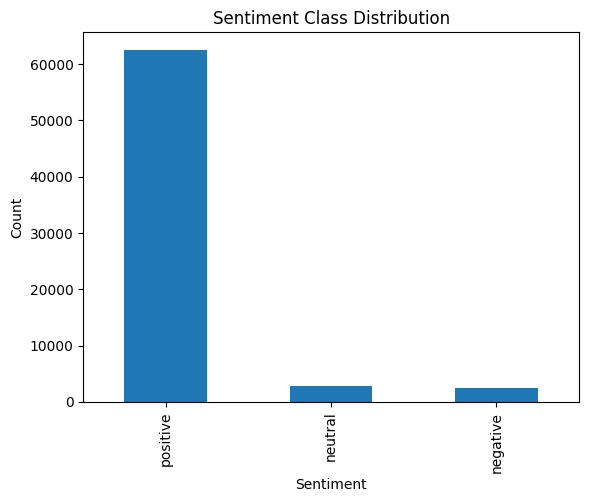

In [8]:
# =========================
# 8. DATA UNDERSTANDING
# =========================
print("\nDataset Information:")
print(df.info())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:")
for i in range(3):
    print(f"\nReview {i+1}:")
    print(df['review'].iloc[i])
    print("Rating   :", df['reviews.rating'].iloc[i])
    print("Sentiment:", df['sentiment'].iloc[i])

# Plot class distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [9]:
# =========================
# 9. NLP PREPROCESSING
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to string
    text = str(text)

    # Lowercasing
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email-like patterns
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization using split() to avoid punkt error
    tokens = text.split()

    # Remove stopwords, remove short words, then lemmatize
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words and len(word) > 2:
            cleaned_word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(cleaned_word)

    # Join tokens back into sentence
    return " ".join(cleaned_tokens)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

print("\nOriginal Review:")
print(df['review'].iloc[0])

print("\nCleaned Review:")
print(df['clean_review'].iloc[0])


Original Review:
This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.

Cleaned Review:
product far disappointed child love use like ability monitor control content see ease


In [10]:
# =========================
# 10. ENCODE TARGET LABELS
# =========================
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_encoded'] = df['sentiment'].map(label_mapping)

print("\nEncoded labels:")
print(df[['sentiment', 'sentiment_encoded']].head())


Encoded labels:
  sentiment  sentiment_encoded
0  positive                  2
1  positive                  2
2  positive                  2
3  positive                  2
4  positive                  2


In [11]:
# =========================
# 11. TRAIN-TEST SPLIT
# =========================
X = df['clean_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining size:", len(X_train))
print("Testing size :", len(X_test))



Training size: 54366
Testing size : 13592


In [12]:
# =========================
# 12. FEATURE ENGINEERING
# =========================
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("\nBoW Train Shape:", X_train_bow.shape)
print("BoW Test Shape :", X_test_bow.shape)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape :", X_test_tfidf.shape)


BoW Train Shape: (54366, 5000)
BoW Test Shape : (13592, 5000)

TF-IDF Train Shape: (54366, 5000)
TF-IDF Test Shape : (13592, 5000)


In [13]:
# =========================
# 13. EVALUATION FUNCTION
# =========================
def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name}")
    print("-" * 50)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return [model_name, acc, prec, rec, f1]

In [14]:
# =========================
# 14. MODEL BUILDING - BAG OF WORDS
# =========================
# Logistic Regression
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)
result_lr_bow = evaluate_model("Logistic Regression + BoW", y_test, y_pred_lr_bow)

# Naive Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)
result_nb_bow = evaluate_model("Naive Bayes + BoW", y_test, y_pred_nb_bow)

# Decision Tree
dt_bow = DecisionTreeClassifier(random_state=42)
dt_bow.fit(X_train_bow, y_train)
y_pred_dt_bow = dt_bow.predict(X_test_bow)
result_dt_bow = evaluate_model("Decision Tree + BoW", y_test, y_pred_dt_bow)


Logistic Regression + BoW
--------------------------------------------------
Accuracy : 0.9418
Precision: 0.9297
Recall   : 0.9418
F1 Score : 0.932

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.58      0.66       502
           1       0.55      0.22      0.31       580
           2       0.95      0.99      0.97     12510

    accuracy                           0.94     13592
   macro avg       0.75      0.60      0.65     13592
weighted avg       0.93      0.94      0.93     13592


Naive Bayes + BoW
--------------------------------------------------
Accuracy : 0.9135
Precision: 0.9127
Recall   : 0.9135
F1 Score : 0.9123

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.60      0.51       502
           1       0.33      0.24      0.28       580
           2       0.96      0.96      0.96     12510

    accuracy                           0.91     13592
   macro

In [15]:
# =========================
# 15. MODEL BUILDING - TF-IDF
# =========================
# Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
result_lr_tfidf = evaluate_model("Logistic Regression + TF-IDF", y_test, y_pred_lr_tfidf)

# Naive Bayes
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
result_nb_tfidf = evaluate_model("Naive Bayes + TF-IDF", y_test, y_pred_nb_tfidf)

# Decision Tree
dt_tfidf = DecisionTreeClassifier(random_state=42)
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt_tfidf.predict(X_test_tfidf)
result_dt_tfidf = evaluate_model("Decision Tree + TF-IDF", y_test, y_pred_dt_tfidf)


Logistic Regression + TF-IDF
--------------------------------------------------
Accuracy : 0.9381
Precision: 0.924
Recall   : 0.9381
F1 Score : 0.9197

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.48      0.60       502
           1       0.63      0.07      0.13       580
           2       0.94      1.00      0.97     12510

    accuracy                           0.94     13592
   macro avg       0.78      0.52      0.57     13592
weighted avg       0.92      0.94      0.92     13592


Naive Bayes + TF-IDF
--------------------------------------------------
Accuracy : 0.9264
Precision: 0.9283
Recall   : 0.9264
F1 Score : 0.8963

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.17      0.29       502
           1       1.00      0.01      0.01       580
           2       0.93      1.00      0.96     12510

    accuracy                           0.93     13592
  


Model Comparison:
                          Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression + BoW  0.941804   0.929723  0.941804  0.931970
3  Logistic Regression + TF-IDF  0.938052   0.923984  0.938052  0.919713
5        Decision Tree + TF-IDF  0.933564   0.930585  0.933564  0.931948
2           Decision Tree + BoW  0.930768   0.929660  0.930768  0.930142
4          Naive Bayes + TF-IDF  0.926427   0.928339  0.926427  0.896292
1             Naive Bayes + BoW  0.913479   0.912747  0.913479  0.912340


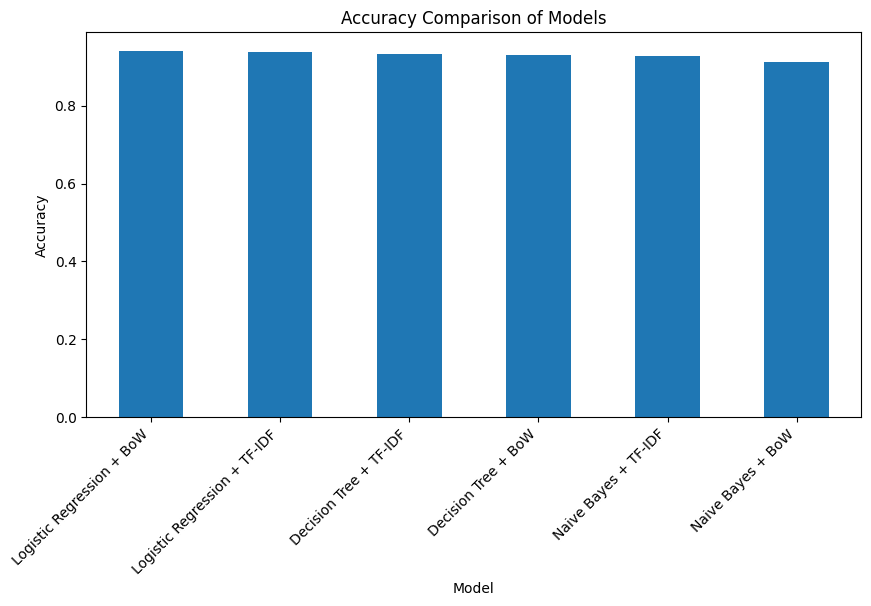

In [16]:
# =========================
# 16. MODEL COMPARISON
# =========================
results = pd.DataFrame([
    result_lr_bow,
    result_nb_bow,
    result_dt_bow,
    result_lr_tfidf,
    result_nb_tfidf,
    result_dt_tfidf
], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

print("\nModel Comparison:")
print(results.sort_values(by='Accuracy', ascending=False))

# Plot model accuracies
results.sort_values(by='Accuracy', ascending=False).plot(
    x='Model', y='Accuracy', kind='bar', figsize=(10, 5), legend=False
)
plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')
plt.show()

In [17]:
# =========================
# 17. CONFUSION MATRIX FOR BEST MODEL
# =========================
cm = confusion_matrix(y_test, y_pred_lr_tfidf)
print("\nConfusion Matrix for Logistic Regression + TF-IDF:")
print(cm)


Confusion Matrix for Logistic Regression + TF-IDF:
[[  243    12   247]
 [   38    43   499]
 [   33    13 12464]]


In [18]:
# =========================
# 18. CUSTOM PREDICTIONS
# =========================
sample_reviews = [
    "This product is excellent and I really love it",
    "Very bad quality and waste of money",
    "The product is okay, not too good and not too bad"
]

sample_clean = [preprocess_text(review) for review in sample_reviews]
sample_vectors = tfidf_vectorizer.transform(sample_clean)
sample_predictions = lr_tfidf.predict(sample_vectors)

reverse_label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

print("\nCustom Predictions:")
for review, pred in zip(sample_reviews, sample_predictions):
    print("\nReview:", review)
    print("Predicted Sentiment:", reverse_label_mapping[pred])


Custom Predictions:

Review: This product is excellent and I really love it
Predicted Sentiment: positive

Review: Very bad quality and waste of money
Predicted Sentiment: negative

Review: The product is okay, not too good and not too bad
Predicted Sentiment: positive


In [19]:
# =========================
# 19. SUMMARY OF FINDINGS
# =========================
print("\nSUMMARY OF FINDINGS")
print("-" * 50)
print("1. Three Amazon review datasets were combined into one dataset.")
print("2. Text preprocessing was performed using lowercasing, URL removal, punctuation removal, stopword removal, and lemmatization.")
print("3. Two feature extraction methods were used: Bag of Words and TF-IDF.")
print("4. Three machine learning models were trained: Logistic Regression, Naive Bayes, and Decision Tree.")
print("5. The best model can be selected from the comparison table using accuracy, precision, recall, and F1 score.")


SUMMARY OF FINDINGS
--------------------------------------------------
1. Three Amazon review datasets were combined into one dataset.
2. Text preprocessing was performed using lowercasing, URL removal, punctuation removal, stopword removal, and lemmatization.
3. Two feature extraction methods were used: Bag of Words and TF-IDF.
4. Three machine learning models were trained: Logistic Regression, Naive Bayes, and Decision Tree.
5. The best model can be selected from the comparison table using accuracy, precision, recall, and F1 score.


## Comparison and Insights

In this project, three Amazon review datasets were combined and cleaned using NLP preprocessing techniques such as lowercasing, removal of punctuation, removal of stopwords, tokenization, and lemmatization. These steps helped in reducing noise and improving the quality of the text data.

Two feature engineering methods were used: Bag of Words (BoW) and TF-IDF. BoW is simple and works well for basic text representation, while TF-IDF gives more importance to meaningful words and reduces the impact of common words.

Three machine learning models were trained: Logistic Regression, Naive Bayes, and Decision Tree. Based on the evaluation results, Logistic Regression with Bag of Words achieved the highest accuracy of 0.9418, making it the best-performing model for this dataset.

It is also observed that the dataset is highly imbalanced, with most reviews being positive. Because of this, the models perform very well on the positive class but struggle with neutral and negative classes.

Overall:
- Best preprocessing: Lowercasing + Stopword removal + Lemmatization
- Best feature extraction: Bag of Words
- Best model: Logistic Regression
- Limitation: Class imbalance affects performance on minority classes

Insights:

To improve performance, techniques such as class balancing, oversampling, or advanced models like Random Forest or XGBoost can be used.

## Conclusion

This project developed a complete sentiment analysis system using Amazon product review datasets. The raw text reviews were cleaned using preprocessing steps such as lowercasing, URL removal, punctuation removal, stopword removal, and lemmatization. After preprocessing, the text data was converted into numerical features using Bag of Words and TF-IDF.

Three machine learning models, Logistic Regression, Naive Bayes, and Decision Tree, were trained and evaluated. Their performance was compared using accuracy, precision, recall, and F1 score. This project helped in understanding the full NLP workflow from raw review text to final sentiment prediction.